In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('clean_data.csv')

In [3]:
# show the first 5 rows
df.head()


,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0


In [4]:
# show the last 5 rows
df.tail()

,Starting (USD),Ending (USD)
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0
10,16800,16500.0
11,16700,NaN


In [5]:
# Random Rows
df.sample(5)

,Starting (USD),Ending (USD)
6,16200,16200.0
3,15900,16200.0
10,16800,16500.0
11,16700,NaN
2,15900,16100.0


In [ ]:
# Shape
df.shape

(11, 2)

In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Starting (USD)  12 non-null     int64  
 1   Ending (USD)    11 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 324.0 bytes


In [7]:
# Summary Statistics
df.describe()

,Starting (USD),Ending (USD)
count,12.000000,11.000000
mean,16229.166667,16000.000000
std,368.324421,376.828874
min,15800.000000,15300.000000
25%,15900.000000,15750.000000
50%,16175.000000,16100.000000
75%,16400.000000,16200.000000
max,16800.000000,16500.000000


In [8]:
# Summary Statistics for all columns
df.describe(include="all")

,Starting (USD),Ending (USD)
count,12.000000,11.000000
mean,16229.166667,16000.000000
std,368.324421,376.828874
min,15800.000000,15300.000000
25%,15900.000000,15750.000000
50%,16175.000000,16100.000000
75%,16400.000000,16200.000000
max,16800.000000,16500.000000


In [9]:
# Drop Unnecessary Columns
df.drop("Date", axis=1, inplace=True, errors="ignore")
df

,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0
5,16150,16100.0
6,16200,16200.0
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0


In [11]:
# Count Missing Values
df.isnull().sum()

Starting (USD)    0
Ending (USD)      1
dtype: int64

In [12]:
df.duplicated()
df.drop_duplicates(inplace=True)
df

,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0
5,16150,16100.0
6,16200,16200.0
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0


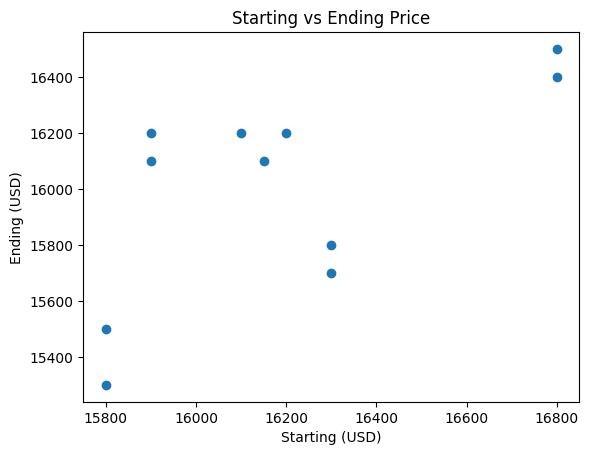

In [13]:
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.title('Starting vs Ending Price')
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.show()

In [17]:
# Outliers Detection
Q1 = df["Starting (USD)"].quantile(0.25)
Q3 = df["Starting (USD)"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Starting (USD)"] < lower) |
    (df["Starting (USD)"] > upper)
]
print(outliers)

Empty DataFrame
Columns: [Starting (USD), Ending (USD)]
Index: []


In [18]:
# Multiple Numeric Columns Outliers
numeric_columns = df.select_dtypes(include="number").columns
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[
    (df[col] >= lower) &
    (df[col] <= upper)
    ]
df

,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0
5,16150,16100.0
6,16200,16200.0
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0


In [19]:
df.sort_values(["Starting (USD)", "Ending (USD)"], inplace=True)
df

,Starting (USD),Ending (USD)
0,15800,15300.0
1,15800,15500.0
2,15900,16100.0
3,15900,16200.0
4,16100,16200.0
5,16150,16100.0
6,16200,16200.0
7,16300,15700.0
8,16300,15800.0
9,16800,16400.0


In [20]:
# Split the data into training and testing sets
features = df.drop("Ending (USD)", axis=1)
target = df["Ending (USD)"]

In [27]:
features

,Starting (USD)
0,15800
1,15800
2,15900
3,15900
4,16100
5,16150
6,16200
7,16300
8,16300
9,16800


In [21]:
target

0     15300.0
1     15500.0
2     16100.0
3     16200.0
4     16200.0
5     16100.0
6     16200.0
7     15700.0
8     15800.0
9     16400.0
10    16500.0
Name: Ending (USD), dtype: float64

In [28]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    features,          # Input features
    target,            # Target variable
    test_size=0.2,     # Use 20% of the data for testing
    random_state=42    # Ensures reproducible results
)

# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate and print the Mean Absolute Error (MAE)
# Measures the average absolute difference between actual and predicted values
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# Calculate and print the Mean Squared Error (MSE)
# Gives more weight to larger prediction errors
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Calculate and print the R² Score
# Indicates how well the model explains the variance in the target variable
# A score closer to 1.0 indicates better performance
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 232.52173913043467
Mean Squared Error: 104413.69124133566
R2 Score: 0.5156065870247314


In [29]:

# y = mx + c
m = model.coef_
c = model.intercept_
y = m * 16700 + c
y


array([16284.86956522])

C:\Users\Omar Faruk\AppData\Local\Temp\ipykernel_4044\2613518906.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


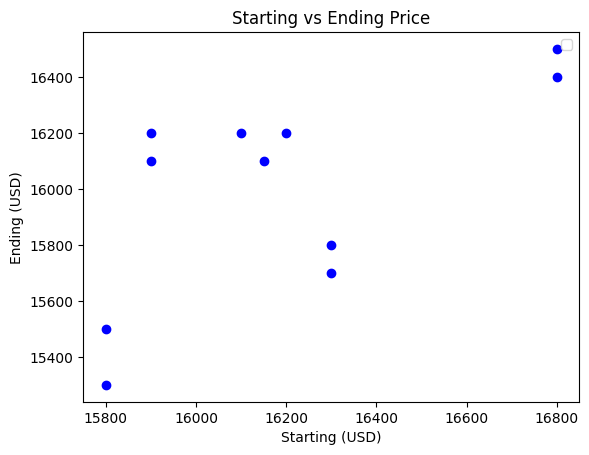

In [42]:
a = features.mean()
b = target.mean()
plt.scatter(df['Starting (USD)'], df['Ending (USD)'], c='blue')
plt.title('Starting vs Ending Price')
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.legend()
plt.show()

In [33]:
# Predict all rows
df['Predicted Y'] = model.predict(features)

df[['Predicted Y']]

,Predicted Y
0,15849.739130
1,15849.739130
2,15898.086957
3,15898.086957
4,15994.782609
5,16018.956522
6,16043.130435
7,16091.478261
8,16091.478261
9,16333.217391
